In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import kendalltau

## Praca z rzeczywistymi danymi

#### a) Zaimportuj zbiór out.radoslaw_email_email 
i zachowaj tylko pierwsze dwie kolumny (dodatkowo przeskocz dwa pierwsze wiersze), następnie stwórz z zaimportowanych danych graf nieskierowany.

In [2]:
G_email = nx.read_edgelist(
    "out.radoslaw_email_email",
    comments='%',
    nodetype=int,
    data=False,
    create_using=nx.MultiDiGraph(),
)

print(f"Wierzchołki: {G_email.number_of_nodes()}")
print(f"Krawędzie: {G_email.number_of_edges()}")


Wierzchołki: 167
Krawędzie: 82927


#### b) Sprawdź ile wierzchołków i krawędzi ma Twój graf 
a następnie pozbądź się wielokrotnych krawędzi i pętli. O ile spadła liczba krawędzi?

In [3]:
G_email.remove_edges_from(nx.selfloop_edges(G_email))
G_email = nx.Graph(G_email)

print(f"Wierzchołki: {G_email.number_of_nodes()}")
print(f"Krawędzie: {G_email.number_of_edges()}")

Wierzchołki: 167
Krawędzie: 3250


#### c) Jaki jest stopień każdego węzła? Stwórz histogram stopni węzłów.
Podobnie stwórz histogram dla miary pośrednictwa (betweenness) oraz bliskości (closeness). Zweryfikuj czy wierzchołki, które mają na-
jwiększe wartości tych miar, są równie wysoko we wszystkich rankingach (możesz użyć np. miary Kendalla).

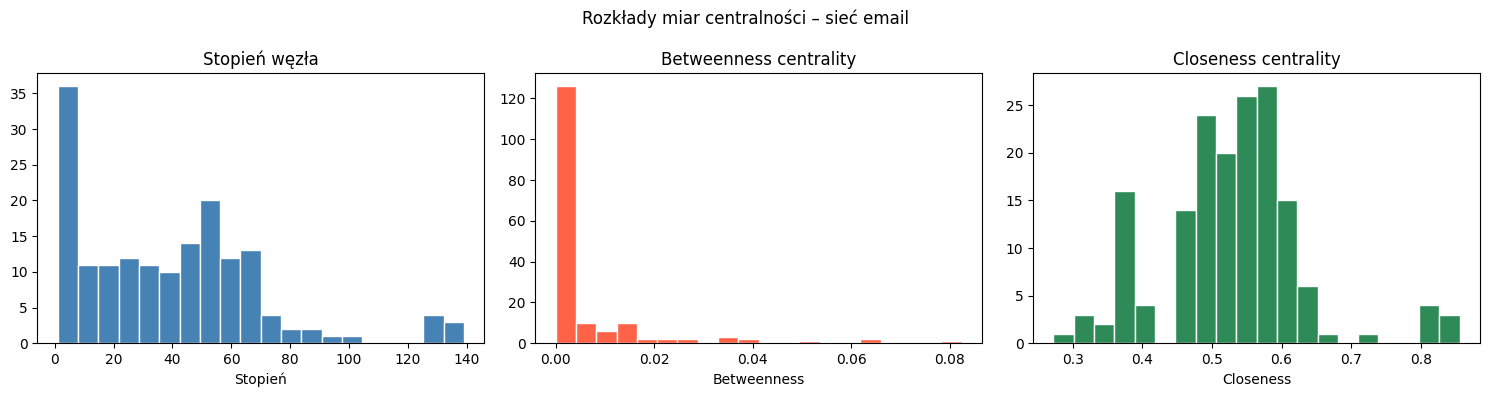

In [4]:
deg_email = dict(G_email.degree())
btw_email = nx.betweenness_centrality(G_email)
cls_email = nx.closeness_centrality(G_email)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(list(deg_email.values()), bins=20, color='steelblue', edgecolor='white')
axes[0].set_title("Stopień węzła")
axes[0].set_xlabel("Stopień")

axes[1].hist(list(btw_email.values()), bins=20, color='tomato', edgecolor='white')
axes[1].set_title("Betweenness centrality")
axes[1].set_xlabel("Betweenness")

axes[2].hist(list(cls_email.values()), bins=20, color='seagreen', edgecolor='white')
axes[2].set_title("Closeness centrality")
axes[2].set_xlabel("Closeness")

plt.suptitle("Rozkłady miar centralności – sieć email")
plt.tight_layout()
plt.show()

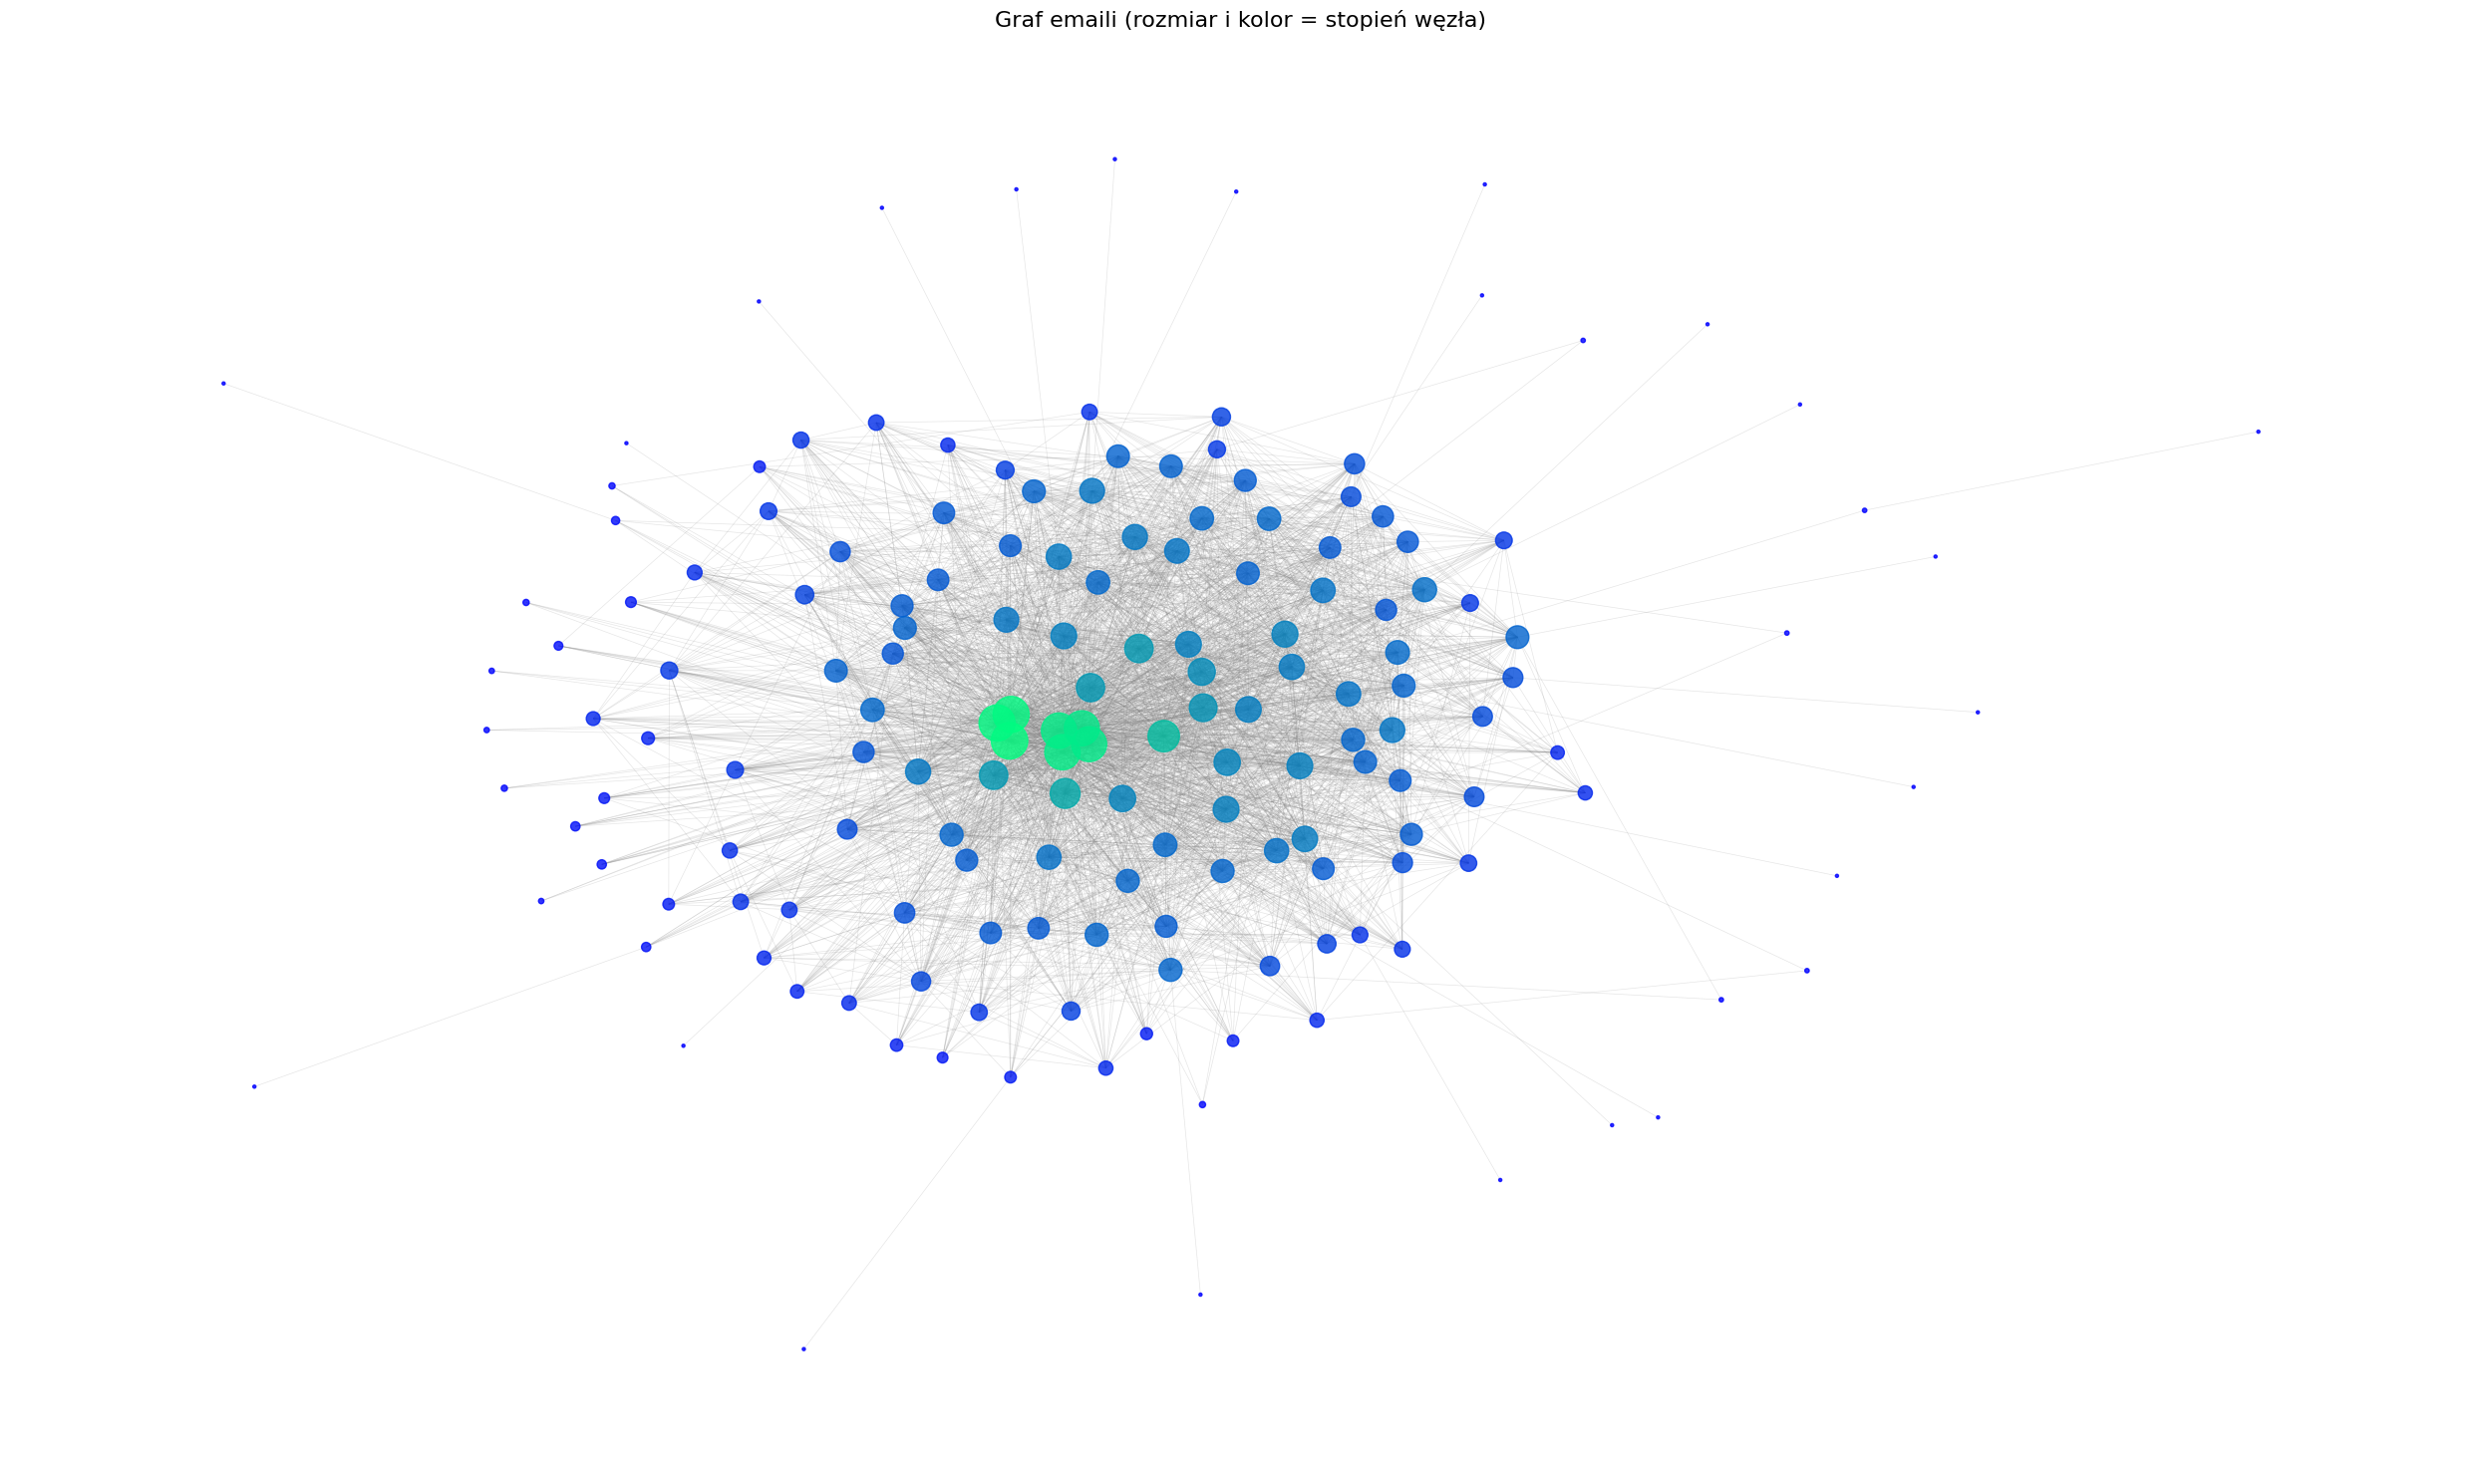

In [5]:
degrees = dict(G_email.degree())

node_sizes = [degrees[n] * 5 for n in G_email.nodes()]
node_colors = [degrees[n] for n in G_email.nodes()]
pos = nx.kamada_kawai_layout(G_email)


plt.figure(figsize=(25, 15))

nodes_real = nx.draw_networkx_nodes(
    G_email,
    pos=pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.winter,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_email,
    pos=pos,
    edge_color="gray",
    alpha=0.2,
    width=0.5
)

plt.title("Graf emaili (rozmiar i kolor = stopień węzła)", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
df_centrality = pd.DataFrame({
    'degree':      deg_email,
    'betweenness': btw_email,
    'closeness':   cls_email
})
df_centrality.head()

,degree,betweenness,closeness
1,130,0.040290,0.813725
2,69,0.012557,0.608059
3,68,0.006057,0.608059
4,65,0.004111,0.592857
5,54,0.002067,0.557047


In [7]:
print("TOP 5 wg stopnia:")
print(df_centrality.nlargest(5, 'degree'))

print("\nTOP 5 wg betweenness:")
print(df_centrality.nlargest(5, 'betweenness'))

print("\nTOP 5 wg closeness:")
print(df_centrality.nlargest(5, 'closeness'))

TOP 5 wg stopnia:
    degree  betweenness  closeness
38     139     0.082420   0.855670
37     136     0.064963   0.842640
45     136     0.064695   0.842640
1      130     0.040290   0.813725
47     130     0.052367   0.813725

TOP 5 wg betweenness:
    degree  betweenness  closeness
38     139     0.082420   0.855670
37     136     0.064963   0.842640
45     136     0.064695   0.842640
47     130     0.052367   0.813725
1      130     0.040290   0.813725

TOP 5 wg closeness:
    degree  betweenness  closeness
38     139     0.082420   0.855670
37     136     0.064963   0.842640
45     136     0.064695   0.842640
1      130     0.040290   0.813725
47     130     0.052367   0.813725


In [8]:
tau_db, p_db = kendalltau(df_centrality['degree'], df_centrality['betweenness'])
tau_dc, p_dc = kendalltau(df_centrality['degree'], df_centrality['closeness'])
tau_bc, p_bc = kendalltau(df_centrality['betweenness'], df_centrality['closeness'])

print(f"\nKorelacja Kendalla degree–betweenness: τ={tau_db:.3f}, p={p_db:.4f}")
print(f"Korelacja Kendalla degree–closeness:   τ={tau_dc:.3f}, p={p_dc:.4f}")
print(f"Korelacja Kendalla betweenness–closeness: τ={tau_bc:.3f}, p={p_bc:.4f}")


Korelacja Kendalla degree–betweenness: τ=0.804, p=0.0000
Korelacja Kendalla degree–closeness:   τ=0.951, p=0.0000
Korelacja Kendalla betweenness–closeness: τ=0.784, p=0.0000


#### d) Ile jest komponentów (connected components) znajduje się w grafie?
Czy przy takiej reprezentacji danych mogą być wierzchołki bez krawędzi?

In [9]:
n_comp = nx.number_connected_components(G_email)
print(f"Liczba komponentów: {n_comp}")

isolated = list(nx.isolates(G_email))
print(f"Izolowane węzły (bez krawędzi): {len(isolated)}")

Liczba komponentów: 1
Izolowane węzły (bez krawędzi): 0


#### e) Jaka jest średnica grafu i czy jest dużo inna od średniej długości ścieżki w grafie

In [10]:
largest_cc_email = max(nx.connected_components(G_email), key=len)
G_email_sub = G_email.subgraph(largest_cc_email)

diam_email = nx.diameter(G_email_sub)
avg_path_email = nx.average_shortest_path_length(G_email_sub)

print(f"\nŚrednica sieci: {diam_email}")
print(f"Średnia długość ścieżki: {avg_path_email:.4f}")
print(f"Różnica: {diam_email - avg_path_email:.4f}")


Średnica sieci: 5
Średnia długość ścieżki: 1.9674
Różnica: 3.0326


#### f) Stwórz graf na nowo, ale tym razem jako skierowany. 
Ustaw wagi krawędzi w grafie w taki sposób, aby waga pomiędzy wierzchołkiem v1 a v2 była wyrażona jako liczba wiadomości wysłanych przez v1 do v2 w stosunku do wszystkich wiadomości wysłanych przez węzeł v1.

In [11]:
G_multi = nx.read_edgelist(
    "out.radoslaw_email_email",
    comments='%',
    nodetype=int,
    data=False,
    create_using=nx.MultiDiGraph(),
)
G_multi.remove_edges_from(nx.selfloop_edges(G_multi))

G_directed = nx.DiGraph()

for u in G_multi.nodes():
    total_out = G_multi.out_degree(u)
    if total_out == 0:
        continue
    for v in G_multi.successors(u):
        count_uv = G_multi.number_of_edges(u, v)
        G_directed.add_edge(u, v, weight=count_uv / total_out)

print(f"Wierzchołki: {G_directed.number_of_nodes()}")
print(f"Krawędzie: {G_directed.number_of_edges()}")

Wierzchołki: 167
Krawędzie: 5783


#### g) Sprawdź czy w takim grafie skierowanym można dostać się z każdego wierzchołka do każdego innego

In [12]:
is_strongly = nx.is_strongly_connected(G_directed)
is_weakly = nx.is_weakly_connected(G_directed)

print(f"Silnie spójny: {is_strongly}")
print(f"Słabo spójny: {is_weakly}")

n_strong = nx.number_strongly_connected_components(G_directed)
n_weak = nx.number_weakly_connected_components(G_directed)

print(f"Liczba silnie spójnych komponentów: {n_strong}")
print(f"Liczba słabo spójnych komponentów: {n_weak}")

Silnie spójny: False
Słabo spójny: True
Liczba silnie spójnych komponentów: 42
Liczba słabo spójnych komponentów: 1


### Dyskusja
Jak odebraliście czytelność i intuicyjność API networkX, czy łatwo było wam
odnaleźć potrzebne funkcje? Czy różnice były intuicyjnie widoczne na wizualiza-
cji pomiędzy sieciami ER oraz BA? Czy zastosowanie współczynnika Kendalla
potwierdziło korelację rankingów? Jaki wpływ ma kierunkowość na średnie dłu-
gości ścieżek?

- API NetworkX jest intuicyjne, nazwy funkcji odpowiadają pojęciom z teorii grafów dzięki czemi łatwo było znaleźć potrzebne metody. 
- Różnice między ER a BA były dobrze widoczne - ER wygląda jednorodnie, a w BA wyraźnie widać dominujące huby. 
- Współczynnik Kendalla potwierdził silną korelację rankingów — τ wynosiło od 0.78 do 0.95 dla wszystkich par miar. 
- Kierunkowość mocno ograniczyła osiągalność - graf nieskierowany był spójny ze średnią ścieżką, a skierowany rozpadł się na 42 komponenty i między wieloma węzłami ścieżka w ogóle nie istnieje.